# (2) CosmoHydro Pk_GO and Pk_hydro vs the MiraTitan-IV emulator

**Question:** How do `Pk_GO` (gravity-only) and `Pk_hydro = Pk-ratio × Pk_GO` from
CosmoHydro_emu compare with the MiraTitan-IV emulator
([`pyccl.emulators.cosmicemu_pk.CosmicemuMTIVPk`](https://ccl.readthedocs.io/en/latest/api/pyccl.emulators.cosmicemu_pk.html))?

CosmoHydro varies only (ωₘ = Ωₘh², σ₈). All other cosmological parameters that
MiraTitan-IV needs (Ω_b h², h, n_s, w₀, wₐ, ω_ν) are **fixed to the Frontier-E values**
from `../fixed_parameters.txt`.

Conventions: k in h Mpc⁻¹ and P(k) in (h⁻¹Mpc)³ throughout (pyccl works in Mpc units;
converted with the appropriate powers of h). MiraTitan-IV is trusted for
k ≲ 5 h Mpc⁻¹; the CosmoHydro Pk grid spans k ∈ [0.016, 8] h Mpc⁻¹ — comparisons are
restricted to the overlap.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

import cosmohydro_emu as ce
import pyccl
from pyccl.emulators.cosmicemu_pk import CosmicemuMTIVPk

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

In [2]:
def load_fixed_params(path='../fixed_parameters.txt'):
    params = {}
    with open(path) as f:
        for line in f:
            line = line.split('#')[0].strip()
            if '=' in line:
                key, val = [s.strip() for s in line.split('=')]
                try:
                    params[key] = float(val)
                except ValueError:
                    params[key] = val
    return params

FP = load_fixed_params()
h = FP['h']
P5 = [FP['kappa_w'], FP['e_w'], FP['M_seed'], FP['v_kin'], FP['epsilon_kin']]

emu_go = ce.load_emulator('Pk_GO')
emu_ratio = ce.load_emulator('Pk-ratio')
k_grid, _ = ce.get_x_grid('Pk_GO')        # h/Mpc
k_grid = np.asarray(k_grid)
print('CosmoHydro k-grid:', k_grid.min(), '-', k_grid.max(), 'h/Mpc,', len(k_grid), 'points')

mt = CosmicemuMTIVPk('tot')

def make_cosmo(omega_m, sigma_8):
    """pyccl Cosmology at (omega_m = Omega_m h^2, sigma_8), everything else Frontier-E."""
    Om = omega_m / h**2
    Ob = FP['Omega_b_h2'] / h**2
    return pyccl.Cosmology(Omega_c=Om - Ob, Omega_b=Ob, h=h,
                           sigma8=sigma_8, n_s=FP['n_s'],
                           w0=FP['w0'], wa=FP['wa'],
                           transfer_function='bbks')  # transfer irrelevant: MT-IV uses params only

def mt_pk(omega_m, sigma_8, z, k_h):
    """MiraTitan-IV P(k) in (Mpc/h)^3 on k_h [h/Mpc]."""
    cosmo = make_cosmo(omega_m, sigma_8)
    pk2d = mt.get_pk2d(cosmo)
    return pk2d(np.asarray(k_h) * h, 1.0 / (1.0 + z), cosmo) * h**3

CosmoHydro k-grid: 0.0222491 - 8.032559 h/Mpc, 511 points


## Gravity-only P(k): CosmoHydro `Pk_GO` vs MiraTitan-IV, fiducial cosmology

MiraTitan-IV emulates the *total matter* nonlinear power spectrum of gravity-only
Mira-Titan simulations, so `Pk_GO` (gravity-only CRK-HACC) is the direct analogue.

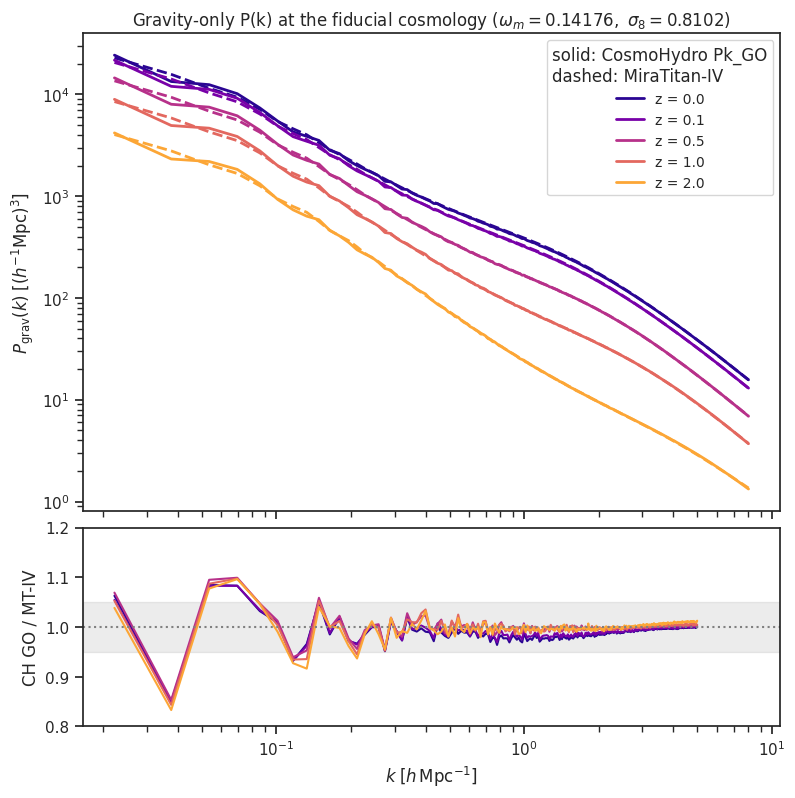

In [3]:
Z_LIST = [0.0, 0.1, 0.5, 1.0, 2.0]
KMAX_MT = 5.0
kmask = k_grid <= KMAX_MT
p_cosmo = [FP['omega_m'], FP['sigma_8']]

fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 9), sharex=True,
                              gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.05})
colors = plt.cm.plasma(np.linspace(0.05, 0.8, len(Z_LIST)))

for z, c in zip(Z_LIST, colors):
    pgo, pgo_std = emu_go.predict(p_cosmo, z=z)
    pmt = mt_pk(*p_cosmo, z, k_grid)
    ax.loglog(k_grid, pgo, color=c, lw=2, label=f'z = {z}')
    ax.loglog(k_grid, pmt, color=c, lw=2, ls='--')
    axr.semilogx(k_grid[kmask], pgo[kmask] / pmt[kmask], color=c, lw=1.5)

ax.set_ylabel(r'$P_{\rm grav}(k)\;[(h^{-1}{\rm Mpc})^3]$')
ax.legend(title='solid: CosmoHydro Pk_GO\ndashed: MiraTitan-IV', fontsize=10)
ax.set_title('Gravity-only P(k) at the fiducial cosmology '
             r'($\omega_m=0.14176,\ \sigma_8=0.8102$)')
axr.axhline(1, color='gray', ls=':')
axr.axhspan(0.95, 1.05, color='gray', alpha=0.15)
axr.set_ylim(0.8, 1.2)
axr.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axr.set_ylabel('CH GO / MT-IV')
plt.tight_layout(); plt.show()

## Full-hydro P(k) vs MiraTitan-IV

`Pk_hydro = Pk-ratio × Pk_GO`. The lower panel (Pk_hydro / MT-IV) shows the expected
**baryonic suppression** at k ≳ 1 h Mpc⁻¹ relative to a gravity-only prediction, on top
of any GO-level offset from the panel above. The dotted curve repeats the emulated
`Pk-ratio` itself — if the two gravity-only spectra agreed perfectly, the solid and
dotted curves would coincide.

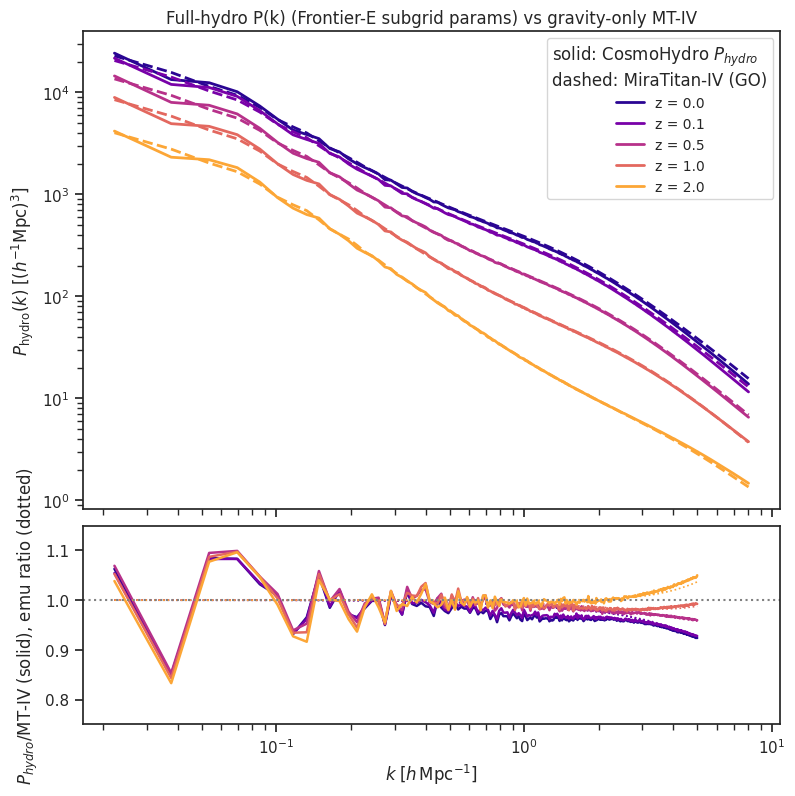

In [4]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(9, 9), sharex=True,
                              gridspec_kw={'height_ratios': [2.4, 1], 'hspace': 0.05})

for z, c in zip(Z_LIST, colors):
    p7 = P5 + p_cosmo
    ratio, _ = emu_ratio.predict(p7, z=z)
    pgo, _ = emu_go.predict(p_cosmo, z=z)
    p_hydro = ratio * pgo
    pmt = mt_pk(*p_cosmo, z, k_grid)
    ax.loglog(k_grid, p_hydro, color=c, lw=2, label=f'z = {z}')
    ax.loglog(k_grid, pmt, color=c, lw=2, ls='--')
    axr.semilogx(k_grid[kmask], p_hydro[kmask] / pmt[kmask], color=c, lw=1.8)
    axr.semilogx(k_grid[kmask], ratio[kmask], color=c, lw=1.2, ls=':')

ax.set_ylabel(r'$P_{\rm hydro}(k)\;[(h^{-1}{\rm Mpc})^3]$')
ax.legend(title='solid: CosmoHydro $P_{hydro}$\ndashed: MiraTitan-IV (GO)', fontsize=10)
ax.set_title('Full-hydro P(k) (Frontier-E subgrid params) vs gravity-only MT-IV')
axr.axhline(1, color='gray', ls=':')
axr.set_ylim(0.75, 1.15)
axr.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axr.set_ylabel(r'$P_{hydro}$/MT-IV (solid), emu ratio (dotted)')
plt.tight_layout(); plt.show()

## Across the (ωₘ, σ₈) box

Ratio CosmoHydro `Pk_GO` / MiraTitan-IV at z = 0 and z = 1 for a 3×3 grid of
cosmologies spanning the CosmoHydro training box (ωₘ ∈ [0.12, 0.155], σ₈ ∈ [0.7, 0.9] —
values chosen slightly inside the edges, where GP predictions degrade).

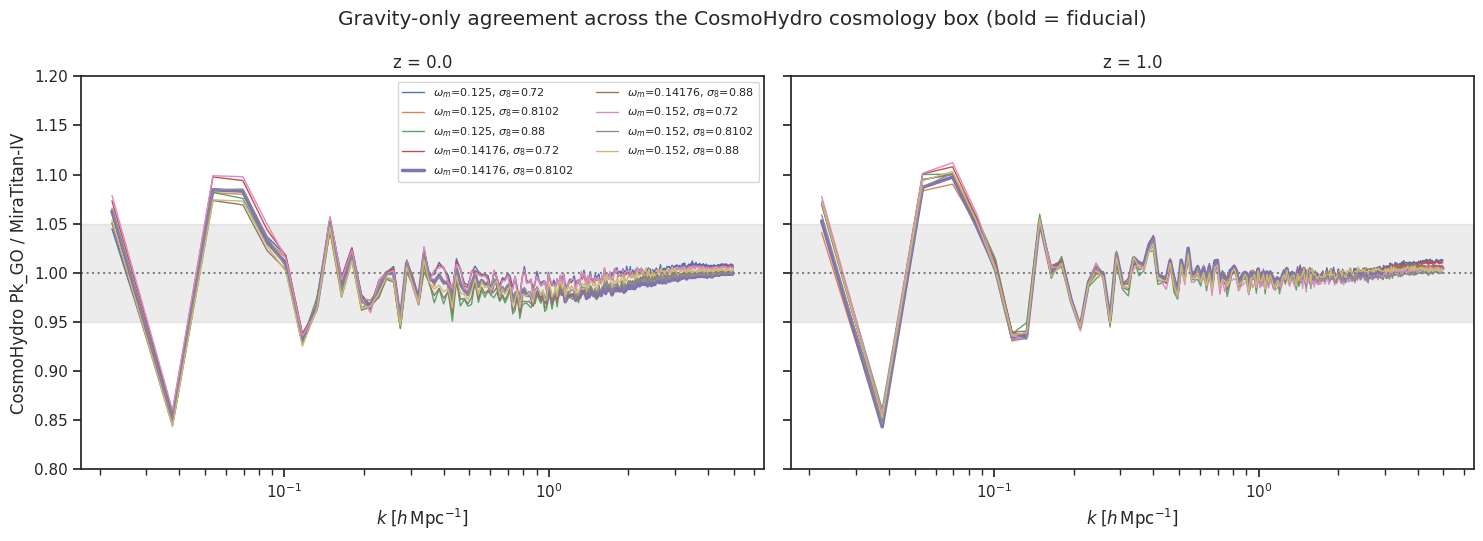

In [5]:
OM_LIST = [0.125, 0.14176, 0.152]
S8_LIST = [0.72, 0.8102, 0.88]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, z in zip(axes, [0.0, 1.0]):
    for om in OM_LIST:
        for s8 in S8_LIST:
            pgo, _ = emu_go.predict([om, s8], z=z)
            pmt = mt_pk(om, s8, z, k_grid)
            lw = 2.5 if (om == 0.14176 and s8 == 0.8102) else 1.0
            ax.semilogx(k_grid[kmask], pgo[kmask] / pmt[kmask], lw=lw,
                        label=f'$\omega_m$={om}, $\sigma_8$={s8}')
    ax.axhline(1, color='gray', ls=':')
    ax.axhspan(0.95, 1.05, color='gray', alpha=0.15)
    ax.set_ylim(0.8, 1.2)
    ax.set_title(f'z = {z}')
    ax.set_xlabel(r'$k\;[h\,{\rm Mpc}^{-1}]$')
axes[0].set_ylabel('CosmoHydro Pk_GO / MiraTitan-IV')
axes[0].legend(fontsize=8, ncol=2)
plt.suptitle('Gravity-only agreement across the CosmoHydro cosmology box (bold = fiducial)')
plt.tight_layout(); plt.show()

## Notes

- MiraTitan-IV was trained on the Mira-Titan Universe suite (gravity-only HACC, large
  volumes, 8-parameter cosmology space including w₀wₐ and massive neutrinos); its quoted
  accuracy is ~2-3% for k ≲ 5 h Mpc⁻¹, z ≤ 2. Here ω_ν = 0 (massless neutrinos, as in the
  CosmoHydro suite).
- CosmoHydro `Pk_GO` comes from a *single* 400 h⁻¹Mpc box per design point, so its largest
  scales (k ≲ 0.05 h Mpc⁻¹) carry sample variance from a handful of modes; deviations
  there are expected and not an emulator error.
- At high k the 1024³-particle resolution of the CosmoHydro GO boxes suppresses power
  relative to the much better-converged Mira-Titan spectra.